In [14]:
# import libraries

# 1. to handle the data
import pandas as pd
import numpy as np

# 2. To Viusalize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# from yellowbrick.cluster import KElbowVisualizer
from matplotlib.colors import ListedColormap

# 3. To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# 4. import Iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 5. Machine Learning
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score

# 6. For Classification task.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,RandomForestRegressor
# from xgboost import XGBClassifier

# 7. Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 8. Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [15]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel(r"D:\MLDP Project\data\heart_disease_clean.xlsx")

# Check the shape and first few rows
print(df.shape)
print(df.head())


(299, 14)
   age_years sex_male_female  chest_pain_type  resting_bp_mmHg  \
0         63            Male   typical angina              145   
1         67            Male     asymptomatic              160   
2         67            Male     asymptomatic              120   
3         37            Male      non-anginal              130   
4         41          Female  atypical angina              130   

   serum_cholesterol_mgdl  fasting_blood_sugar_gt120 resting_ecg_result  \
0                     233                       True     lv hypertrophy   
1                     286                      False     lv hypertrophy   
2                     229                      False     lv hypertrophy   
3                     250                      False             normal   
4                     204                      False     lv hypertrophy   

   thalch  exercise_induced_angina  st_depression_exercise  \
0     150                    False                     2.3   
1     108         

In [16]:
# Checking for missing values
df.isnull().sum()


age_years                    0
sex_male_female              0
chest_pain_type              0
resting_bp_mmHg              0
serum_cholesterol_mgdl       0
fasting_blood_sugar_gt120    0
resting_ecg_result           0
thalch                       0
exercise_induced_angina      0
st_depression_exercise       0
st_slope_peak_exercise       0
num_major_vessels            0
thal_defect_type             0
severity_label               0
dtype: int64

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Updated strong features list with categorical + age + cholesterol
strong_features = [
    'thalch',
    'num_major_vessels',
    'st_depression_exercise',
    'age_years',                 # numeric
    'serum_cholesterol_mgdl',    # numeric
    'resting_bp_mmHg',
    'chest_pain_type',           # categorical
    'thal_defect_type'           # categorical
]

# Reduce dataframe to selected features + target
df_reduced = df[strong_features + ['severity_label']]

# Define target column
col_y = 'severity_label'
y = df_reduced[col_y]

# Drop target column only
X = df_reduced.drop(col_y, axis=1)

# ✅ One-Hot Encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split data into train and test sets
test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state
)


In [18]:
print(X_train.shape)
#sanity check

(209, 11)


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.6222222222222222


In [20]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)
print("New Random Forrest Accuracy [RandF. with FI]:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

New Random Forrest Accuracy [RandF. with FI]: 0.6222222222222222
              precision    recall  f1-score   support

        Mild       0.36      0.21      0.27        19
    Moderate       0.50      0.30      0.38        10
      Normal       0.75      0.88      0.81        56
      Severe       0.00      0.00      0.00         4
 Very Severe       0.00      0.00      0.00         1

    accuracy                           0.62        90
   macro avg       0.32      0.28      0.29        90
weighted avg       0.60      0.62      0.60        90



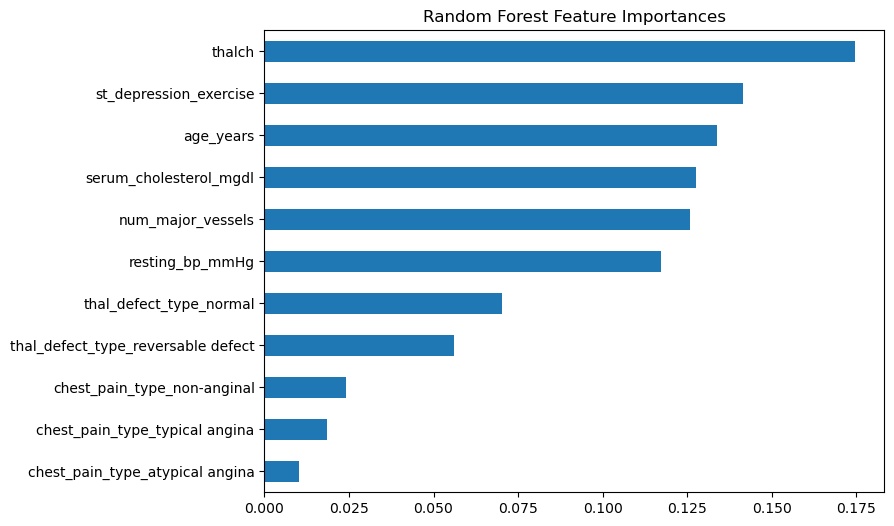

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

fi = pd.Series(rf.feature_importances_, index=X_train.columns)
fi.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Random Forest Feature Importances")
plt.show()


In [22]:
import optuna
import numpy as np
from time import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Track runtime
start = time()
speed = {}

def objective(trial):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Auto-detect categorical and numeric columns
    categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features)
        ]
    )

    # Hyperparameter search space for Random Forest
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Build pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42
        ))
    ])

    # Train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return acc

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Record runtime
speed['RandomForest'] = np.round(time() - start, 3)

# Print best parameters
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {trial.value}")
print("  Parameters:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print(f"Run time: {speed['RandomForest']}s")

# Evaluate best model on train/test
best_params = trial.params
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(**best_params, random_state=42))
])

model.fit(X_train, y_train)

# Metrics
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = accuracy_score(y_test, model.predict(X_test))

print(f"Accuracy train: {acc_train:.6f}, Accuracy test: {acc_test:.6f}")



[I 2026-01-22 15:48:22,592] A new study created in memory with name: no-name-39052ada-934c-4890-984d-a802e7a0c7d5
[I 2026-01-22 15:48:22,938] Trial 0 finished with value: 0.6166666666666667 and parameters: {'n_estimators': 257, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6166666666666667.
[I 2026-01-22 15:48:23,117] Trial 1 finished with value: 0.65 and parameters: {'n_estimators': 138, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.65.
[I 2026-01-22 15:48:23,371] Trial 2 finished with value: 0.6 and parameters: {'n_estimators': 211, 'max_depth': 2, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.65.
[I 2026-01-22 15:48:23,537] Trial 3 finished with value: 0.6833333333333333 and parameters: {'n_estimators': 121, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features':

Best trial:
  Accuracy: 0.7
  Parameters:
    n_estimators: 151
    max_depth: 10
    min_samples_split: 4
    min_samples_leaf: 1
    max_features: log2
Run time: 4.298s
Accuracy train: 0.987448, Accuracy test: 0.700000


In [23]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Example: assume X is your numeric feature matrix
# 1. Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA(n_components=5)  # choose number of components
X_pca = pca.fit_transform(X_scaled)

# 3. Inspect explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum())


Explained variance ratio: [0.25946679 0.13016544 0.11700746 0.10721035 0.09503939]
Cumulative explained variance: [0.25946679 0.38963223 0.50663969 0.61385004 0.70888943]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)
print("New Random Forrest Accuracy [RandF. with FI & Optuna]:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

New Random Forrest Accuracy [RandF. with FI]: 0.8666666666666667
              precision    recall  f1-score   support

        Mild       1.00      0.69      0.82        13
    Moderate       0.75      0.60      0.67         5
      Normal       0.88      1.00      0.93        35
      Severe       0.60      0.75      0.67         4
 Very Severe       1.00      0.67      0.80         3

    accuracy                           0.87        60
   macro avg       0.84      0.74      0.78        60
weighted avg       0.88      0.87      0.86        60



In [25]:
import os
import joblib

# Make sure the folder exists
os.makedirs("Models", exist_ok=True)

# Save model to file 
joblib.dump(model, "Models/trained_HD_model.pkl")
print("Model saved to Models/trained_HD_model.pkl  ")
 

Model saved to Models/trained_HD_model.pkl  


In [26]:
import joblib

# Load the trained model
model = joblib.load("Models/trained_HD_model.pkl")


In [27]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on the test set
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed classification report (precision, recall, f1 per class)
print(classification_report(y_test, y_pred))


Accuracy: 0.7
              precision    recall  f1-score   support

        Mild       0.33      0.15      0.21        13
    Moderate       0.43      0.60      0.50         5
      Normal       0.83      1.00      0.91        35
      Severe       0.40      0.50      0.44         4
 Very Severe       0.00      0.00      0.00         3

    accuracy                           0.70        60
   macro avg       0.40      0.45      0.41        60
weighted avg       0.62      0.70      0.65        60

